# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

Although linear models are simple and interpretable, they often times are not able to capture the true restraints or limitations in real life. The outcome for a plain linear model is a numeric between positve and negative infinity but this does not reflect reality in all cases. Sometimes, in order for the outcome to be valid, there must be a way to control the outcome so it is within a legitimate window of numbers (such as with probabilities that are within 0 to 1, count data with integers, or survival times that can not be negative). Therefore, the critical advantage is to be able to transform the latent linear predictor through an activation function in order to accomodate limitations by utilizing a latent linear variable with an activation function. This allows the model to retain a linear structure in the predictor while still giving outputs that are in the valid space by mapping this latent predictor into valid outcomes. You also have the flexibility with a GLM to alter its activation function and interaction with your latent variable in order to accomodate different types of logically restricted data outcomes. Ultimately, GLMs are able to take the advantages of a linear model in its simplicity and interpretability while being able to translate those results into real constraints to make more meaningful and significant data.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

The binary and categorical cross entropy are effective loss functions for fitting logistic regression models because they measure effectively how well the predicted probabilities match the actual outcomes. Unlike the Brier Score, this method is better equipped to handle and compare the model's high probability outcomes to what would be considered correct and this allows it to scale the penalty based on a model's relative confidence as well as accuracy. This methodology is also based on the maximum likelihood estimation, which goes hand in hand with fitting logistic regression models built for mapping probability of outcomes since minimizing cross entropy and thus maximizing the likelihood of real data and outcomes. The steep penalty onto low probabilities for the true outcome and the natural interaction with probabilities itself make it ideal to fit logistic regression models. Yes, binary and categorical cross entropy are slightly different cases in terms of number of classes but the fundamental concept as to why they are effective is shared.

3. True or false, and explain: Logistic regression is a linear model.

False. A logistic regression is not a linear model because its equation for p hat is fundamentally not linear. Though it may have linear characteristics in its parameters and features, it should not be considered overall a linear model because its outputs are non-linear.

4. True or false, and explain: Logistic regression cannot be used for classification.

This is false. Logistic regression can indeed be used for classification if we report the most likely outcome as our classification, since a logistic regression is well equipped to give us probabilities of events or labels for a given data. Ultimatley, a logistic regression like other regressions in this context can be used for classification here if we attribute and relate probabilities to classification outcoems and predictions.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. In a logistic regression, the coefficient no longer represents the change in the predicted value for a 1 unit change in the explanatory variable of interest anymore in this context. In other words, the direct coefficient effects are no longer linear and is not as simple as assumin changes in x affect y in proportion to b anymore. In a model with the latent space and an activation function that is non-linear, though some may attempt to interpret these values as "Log-Odds", the effect on the outcome and predicted probability does not follow the same trend exactly as a simple linear model. Further interpretation of these coefficients become tricky outside of sign differences such as whether it is positive or negative that may correlate to likelihood.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. The state of having nonlinear predictions overall does not erase the necessity and advantages of feature engineering in order to construct the best possible variabels and features for the model to use. Analyzing and constructing specific interactions, encodings, and transformations of our variables are needed to get it to work the best it can and create interpretable data. Logistic regression is also linear in the latent and features space, meaning one should not assume it is automatically able to map complex non-linear interactions on its own since the boundary of decision remains linear. So no, logistic regression models still benefit and should receive proper feature engineering.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Logistic regression is a type of analysis we have avaliable to us but it is wrong to say that there is no world you would use the usual linear model over the logistic regression model. Logistic regression models here excel at being able to maintain valid restrictions and outcomes to the data through probability predictions, but if the data is better represented continously, a simple ordinary least squares linear model may be better equipped to present the data in a dimension that makes sense while also maintaing a level of efficacy. They are different types of tools avaliable to data scientists, making this statement incorrect.


**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

I handled missing values by dropping the rows with them. Any rows with NaN in the variables of interest was dropped. This allows the model to rely on complete observations and reduces the likelihood of complications down the road.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

It appears that the variables "Debtor" and "Age at enrollment" predict a higher dropout probability (though the latter to a lesser extent), while the variables "Tuition fees up to date" and "Scholarship holder" predict a lower dropout probability. This is honestly pretty intuitive. Having debt and older adults have a higher dropout probability while those who have earned scholarships (which is likely monetary aid) and are good at paying their tuition fees are likely going to not drop out since these factors indicate a more stable academic and financial life. Being up to date on tuition seems to reduce dropout risk according to the coefficients by a relatively large margin.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

Honestly, being up to date on tuition fees reduces the predicted dropout probability on all age groups, but the effect seems to be the biggest for the younger age ranges (around the 20s). Being up to date on tuition fees seem to reduce predicted dropout probabilty for younger adults the most. In general and based on broad trends, the older the age, the less the impact of tuition fees being up to date on dropout probability. This makes intuitive sense since younger folks may have less established financial bases, meaning that an indicator of financial stability such as up-to-date tuition payments will present this observation. Younger folks who are not up to date and may be going through financial trouble will have a higher chance of not being able to continue their education. On average, it appears that being up to date on tuition seems to affect the predicted dropout probability by 0.62, which is the difference in mean predicted probabilities and is very large. This average may seem skewed but this may be due to class-data imbalanace with higher average groups dominainting in the data set. Some missing values in this case despite data cleaning may simply indicate that the particular combination of variables is not present in the data set, giving a NaN value here.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

It says the accuracy is about 0.76 or 76% ish.

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

The linear and logistic model both have very similar distributions in general. However, the linear model gives probability estimates for values that do not make sense in a realistic setting. For example, the linear model is giving estimates for probability values of 1.2, when probabilities are supposed to range from 0 to 1. This shows a clear limitation of the linear model (the usual one) against a model that takes the latent space into consideration. A model such as a logistic regression is able to accomodate real world limitations by limiting its probabilities to 0 to 1.0, while a linear model fails to do this. However, beside the limitation in ranges of outputs, the shapes honestly look quite similar and have similar trends.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

It appears that both the linear and the logistic model supports two variables being correlated with an increased risk of dropping out based on the prediction models. Both models suggest that having debt and being older increases the risk of dropping out (though the coefficient for age on the logistic model is quite small). Both mdoels also demonstrate that being up to date on tuition payments and having scholarships reduce the predicted probability of dropping out, indicating that financial burden is a significant factor in drop out probability. Despite the fundamental difference in what the coefficients mean, the general direction shows that both models display similar results. The kinds of interventions that would help at-risk students stay enrolled are likely financial and grants, better student aid, and lowering the cost of attendance would likely help lower the chances a student has to drop out of college based on these findings.

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

After making a hard classification and computing a confusion matrix, it is clear that the model has an easier time predicting some classes more than others. Based on the more easily interpretable confusion matrix results, it appears that the model has a easier time assigning drop out and graduate to the correct category and struggles with the enrolled cateogry. This could make sense because enrolled may appear as the awkward middle class and therefore could be harder for the model to predict properly. Interestingly, the enrolled column is missing in my confusion matrix, further reinforcing the implication that the model struggles to assign the enrolled label and in fact can miss it entirely. Using predict_proba to predict probabilities instead gives us a look into the data and the data shows that higher probabilities tend to exist on either "extreme" relatively, either on drop out or graduate. This is in line with the observations from the hard classification. The hard classification does not always predict every class, especially if the class is harder to predict, an intermediate class, or simply does not get factored as much in the weighing process. We saw this with the confusion matrix results. On the other hand, the predicted probabilities predict every class since we get a probability for literally every possible class for every observation. This is because hard classification assigns each observation one prediction which is the most likely while a proba method will give the probabilty for every possible class, meaning they are all represented to an extent and it predicts every class. So to answer the quesiton, the outputs are different, and while hard classification won't always 'predict' every class necessarily since it gives one output for an observation, the predicted probabilities with the proba method will since that is what it is designed to do.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

df = pd.read_csv("/content/data.csv", sep=";")

df = df[["Debtor","Tuition fees up to date","Scholarship holder","Age at enrollment","Curricular units 1st sem (approved)","Target"]]
df = df.dropna() #Missing values drop
df.columns = df.columns.str.strip()

df["binarytarget"] = (df["Target"] == "Dropout").astype(int)

from sklearn.linear_model import LogisticRegression

X = df[["Debtor","Tuition fees up to date","Scholarship holder","Age at enrollment"]]
y = df["binarytarget"]

model = LogisticRegression(max_iter=5000, penalty=None)
model.fit(X, y)

pd.DataFrame({'Variable':model.feature_names_in_,'Coefficient':model.coef_[0]})

,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


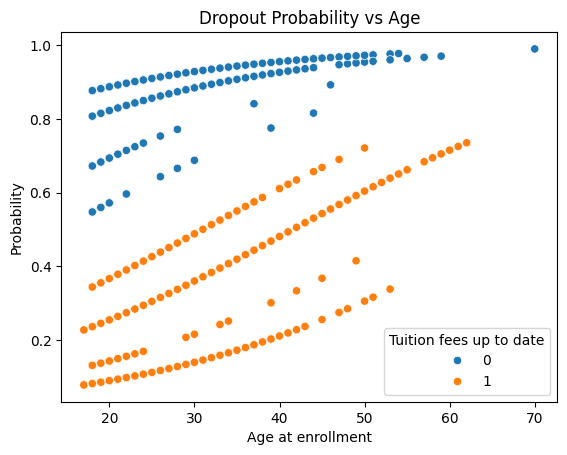

Tuition fees up to date         0         1       dif
Age at enrollment                                    
19                       0.819688  0.195178  0.624510
21                       0.843269  0.227377  0.615892
25                       0.888687  0.281206  0.607481
23                       0.866144  0.259901  0.606243
20                       0.816559  0.213050  0.603509
18                       0.786936  0.186091  0.600845
24                       0.873980  0.279497  0.594483
22                       0.824800  0.239605  0.585195
26                       0.870139  0.294550  0.575589
27                       0.895073  0.321279  0.573794
32                       0.906645  0.348563  0.558082
31                       0.914399  0.357915  0.556483
29                       0.898441  0.345307  0.553134
28                       0.883165  0.334016  0.549149
36                       0.925044  0.385449  0.539595
33                       0.909589  0.378743  0.530846
35                       0.9

In [ ]:
dop = model.predict_proba(X)
dop = [ row[1] for row in dop ]
df["predicted"] = dop

sns.scatterplot(x=df["Age at enrollment"],y=df["predicted"],hue=df["Tuition fees up to date"])
plt.title("Dropout Probability vs Age")
plt.xlabel("Age at enrollment")
plt.ylabel("Probability")
plt.show()

byage = df.groupby(["Age at enrollment", "Tuition fees up to date"])["predicted"].mean().unstack()

byage["dif"] = byage[0] - byage[1]

print(byage.sort_values("dif", ascending=False))

effect = df.groupby("Tuition fees up to date")["predicted"].mean()
effect2 = effect[0] - effect[1]
print(effect)

print(effect2)

tab = pd.crosstab(y, model.predict(X))
acc = np.trace(tab) / len(y)
print(tab)
print('Accuracy: ', acc)

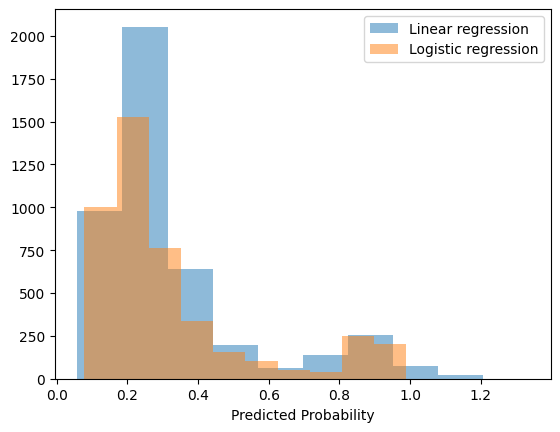

[ 0.08518283 -0.51216587 -0.17647159  0.00948704]


,Variable,Coefficient
0,Debtor,0.085183
1,Tuition fees up to date,-0.512166
2,Scholarship holder,-0.176472
3,Age at enrollment,0.009487


In [ ]:
from sklearn.linear_model import LinearRegression

linmodel = LinearRegression()
linmodel.fit(X, y)
linprobs = linmodel.predict(X)

plt.hist(x=linprobs, alpha = 0.5, label='Linear regression')
plt.hist(x=dop, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

print(linmodel.coef_)
pd.DataFrame({'Variable':linmodel.feature_names_in_,'Coefficient':linmodel.coef_})

In [ ]:
X = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y = df["Target"]

mnl = LogisticRegression(penalty=None).fit(X,y)

mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
print(mnl_coef)

print(pd.DataFrame(mnl.predict_proba(X)))

print(pd.crosstab( y, mnl.predict(X)))

tab = pd.crosstab( y, mnl.predict(X))
acc = np.trace(tab)/len(y)
print('Accuracy: ', acc)

     Debtor  Tuition fees up to date  Curricular units 1st sem (approved)
0  0.364253                -1.782824                            -0.289422
1  0.279227                 0.207343                            -0.025537
2 -0.643480                 1.575481                             0.314959
             0         1         2
0     0.680560  0.210486  0.108954
1     0.706615  0.145494  0.147892
2     0.954343  0.040341  0.005316
3     0.117346  0.176786  0.705867
4     0.183691  0.212551  0.603758
...        ...       ...       ...
4419  0.183691  0.212551  0.603758
4420  0.790188  0.149440  0.060372
4421  0.071581  0.140405  0.788013
4422  0.183691  0.212551  0.603758
4423  0.117346  0.176786  0.705867

[4424 rows x 3 columns]
col_0     Dropout  Graduate
Target                     
Dropout      1054       367
Enrolled      280       514
Graduate      146      2063
Accuracy:  0.35443037974683544


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

The missing values were handled the same way as the previous question and the rows with NaN in the variables of interest were dropped to avoid further complications associated with them.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

The model estimates slightly higher survival probabilities with the drug placebo, which means that the model does not provide enough evidence to declare that the drug is able to improve survival probability. Higher bilirubin is associated with a lower survival probability and this implies that lower bilirubin is associated with a higher survival probability. Both statuses of edema contribute to a lower survival probability, but the more serious edema variant that is implied not to be solvable by diuretics seems to have a greater magnitude of change and thus a greater impact on lower survival.

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

It is very hard to say. The difference in survival probability is not evident or clear, and the placebo and the drug "lines" (trend of points) do not have a significant difference as they both essentially trail or follow each other along the entire graph. Given that observation, I would say no level of bilirubin shows strong evidence that the drug increases the patient survival rate if we were to go off only the graph. After some analysis it looks like generally lower bilirubin levels seem to create conditions where the drug seems to increase patient survival rate, but this is again difficult to see a clear trend. On average, it looks like patients who take the drug actually has a lower probability of survival (only by about 1.9% lower), but this is very miniscule in terms of predicted probabilities. The method to find this average is similar to the last question and I took a difference of averages between the groups of interest. The NaN values again may indicate that there were no observed combinations for that particular bilirubin and drug pair. Regardless, there appears to be not great evidence that the drug actually increases survival probability, but lower levels of bilirubin may create better enviornments for the drug.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

The accuracy was found to be about 0.74 or 74%.

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

Much like the previous question, both the logistic and linear models have a very similar distribution of probabilities, and the general shape is very similar as well as which variables are associated with higher or lower survivability probabilities. The same trends observed and noted in the previous question are consistent here in the linear model as well in terms of the effect of edema, bilirubin and the placebo drug. However, characteristic of linear models, not all the probabilities are necessarily valid. In fact, we have probabilities that are below 0 and are literally negative. This is not a valid outcome, demonstrating again the limitations of a linear model compared to a logistic regression model used here. Not all outcomes will be interpretable or valid, and this is why a logistic regression is more appropriate. In terms of the actual trends in data and the distributions however, both models produce similar results. The critical distinction is that the logistic regression model gives probability results in the restricted, realistic dimensions of 0 to 1.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

Much like the previous question, the hard classification does not predict every class necessarily. Hard classification predicts and matches the observation to its most likely outcome as determined by the model, so there is no guarantee every class is represented or predicted for the data. This is shown in the output as only stage 3 and 4 got predicted, meaning that the features weighing those stages dominated the model and stages 1 and 2 did not get representation in the final outcome. The predicted probabilities received by proba did predict (give a value for) every class as it fundamentally outputs the predicted probability for each class, meaning that a value for each class is shown for every observation regardless of the accuracy or whether the hard classification covers every class in its outcome. The outputs are differnt for these methods and that is why we see this discrepency. The model performance in general seems poor however and is not dependable to predict the stage of the disease based on these two variables alone.

In [ ]:
import pandas as pd

df = pd.read_csv("/content/cirrhosis.csv")

df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df = df.dropna()

df["Status"] = (df["Status"] != "D").astype(int)

X = pd.get_dummies(df[["Edema", "Drug"]], drop_first=True)

X["Bilirubin"] = df["Bilirubin"]

y = df["Status"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

pd.DataFrame({'Variable':model.feature_names_in_,'Coefficient':model.coef_[0]})

,Variable,Coefficient
0,Edema_S,-0.450677
1,Edema_Y,-1.611049
2,Drug_Placebo,0.231225
3,Bilirubin,-0.351424


            0         1
0    0.995164  0.004836
1    0.270268  0.729732
2    0.392418  0.607582
3    0.426392  0.573608
4    0.397424  0.602576
..        ...       ...
307  0.224565  0.775435
308  0.186869  0.813131
309  0.313801  0.686199
310  0.336936  0.663064
311  0.654315  0.345685

[312 rows x 2 columns]
None


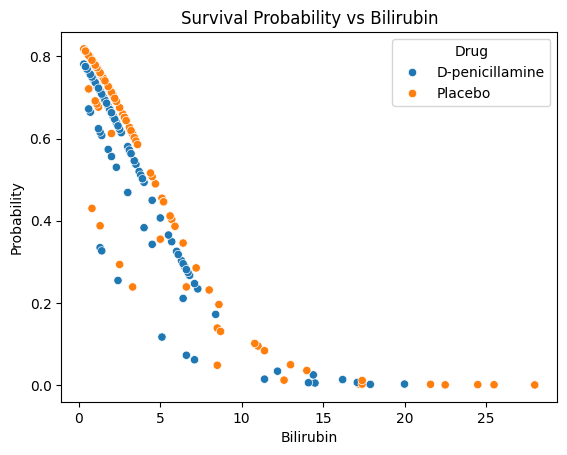

Drug       D-penicillamine   Placebo       dif
Bilirubin                                     
2.5               0.622757  0.484415  0.138343
5.0               0.406780  0.355089  0.051691
0.8               0.750014  0.750754 -0.000740
2.0               0.636382  0.662530 -0.026148
1.0               0.736606  0.766523 -0.029916
...                    ...       ...       ...
21.6                   NaN  0.001609       NaN
22.5                   NaN  0.000368       NaN
24.5                   NaN  0.000912       NaN
25.5                   NaN  0.000642       NaN
28.0                   NaN  0.000170       NaN

[85 rows x 3 columns]
Drug
D-penicillamine    0.590054
Placebo            0.608902
Name: predictedc, dtype: float64
-0.018848501038509102
col_0    0    1
Status         
0       59   66
1       16  171
Accuracy:  0.7371794871794872


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

cir = model.predict_proba(X)
cir = [ row[1] for row in cir ]
df["predictedc"] = cir

print(print(pd.DataFrame(model.predict_proba(X))))

sns.scatterplot(x=df["Bilirubin"],y=df["predictedc"],hue=df["Drug"])
plt.title("Survival Probability vs Bilirubin")
plt.xlabel("Bilirubin")
plt.ylabel("Probability")
plt.show()

byage = df.groupby(["Bilirubin", "Drug"])["predictedc"].mean().unstack()

byage["dif"] = byage["D-penicillamine"] - byage["Placebo"]

print(byage.sort_values("dif", ascending=False))

effect = df.groupby("Drug")["predictedc"].mean()
effect2 = effect["D-penicillamine"] - effect["Placebo"]
print(effect)

print(effect2)

tab = pd.crosstab(y, model.predict(X))
acc = np.trace(tab) / len(y)
print(tab)
print('Accuracy: ', acc)

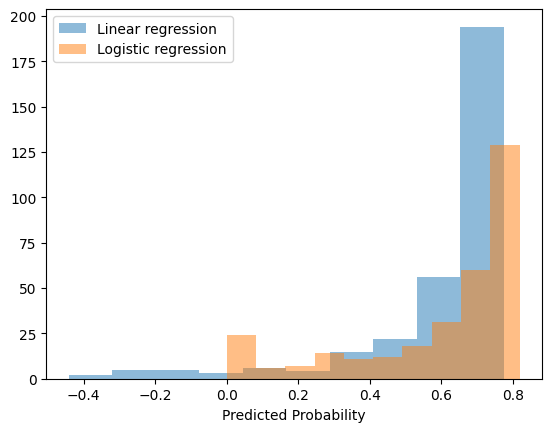

[-0.11888048 -0.34830708  0.05063991 -0.0390676 ]


,Variable,Coefficient
0,Edema_S,-0.118880
1,Edema_Y,-0.348307
2,Drug_Placebo,0.050640
3,Bilirubin,-0.039068


In [ ]:
from sklearn.linear_model import LinearRegression

linmodel = LinearRegression()
linmodel.fit(X, y)
linprobs = linmodel.predict(X)

plt.hist(x=linprobs, alpha = 0.5, label='Linear regression')
plt.hist(x=cir, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

print(linmodel.coef_)
pd.DataFrame({'Variable':linmodel.feature_names_in_,'Coefficient':linmodel.coef_})

In [ ]:
df = df[["Stage", "Edema", "Bilirubin"]].dropna()

X = pd.get_dummies(df[["Edema"]], drop_first=True)
X["Bilirubin"] = df["Bilirubin"]

y = df["Stage"]

mnl = LogisticRegression(penalty=None).fit(X,y)

mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
print(mnl_coef)

print(pd.DataFrame(mnl.predict_proba(X)))

print(pd.crosstab( y, mnl.predict(X)))

tab = pd.crosstab( y, mnl.predict(X))
acc = np.trace(tab)/len(y)
print('Accuracy: ', acc)

    Edema_S   Edema_Y  Bilirubin
0 -9.386383 -4.528670  -0.442467
1  2.756761  0.759798   0.083879
2  3.115884  1.034721   0.156874
3  3.513738  2.734151   0.201714
                0         1         2         3
0    2.965087e-08  0.022548  0.124085  0.853367
1    7.611338e-02  0.252747  0.397286  0.273854
2    2.404877e-07  0.175628  0.404099  0.420273
3    1.887425e-07  0.170140  0.403070  0.426790
4    2.053816e-02  0.228845  0.425472  0.325145
..            ...       ...       ...       ...
307  1.108591e-01  0.254674  0.380373  0.254094
308  1.108591e-01  0.254674  0.380373  0.254094
309  5.456136e-02  0.248464  0.408039  0.288936
310  4.606375e-02  0.245649  0.412347  0.295941
311  3.454602e-03  0.186700  0.432095  0.377751

[312 rows x 4 columns]
col_0  3.0  4.0
Stage          
1.0     16    0
2.0     61    6
3.0    102   18
4.0     74   35
Accuracy:  0.07051282051282051


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

Image provided in the repository

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?